In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import string

plt.rcParams.update(
    {
        "figure.dpi": 150,
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "DejaVu Serif",
    }
)

CHECKPOINT = Path("checkpoint/checkpoint_mermaid.jsonl")
REPORT = Path("data/sonar_report_mermaid_stratified.json")

# ── Load checkpoint ───────────────────────────────────────────
records = []
with CHECKPOINT.open(encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rec = json.loads(line)
        if rec.get("type") == "issue":
            records.append(rec)

df = pd.DataFrame(records)
df = df.drop_duplicates(subset="id", keep="last").reset_index(drop=True)

# Expand agent_durations dict into columns
durations = df["agent_durations"].apply(pd.Series).add_prefix("dur_")
df = pd.concat([df.drop(columns="agent_durations"), durations], axis=1)

# ── Join with report for issue type ──────────────────────────
report = json.load(REPORT.open())
type_map = {issue["id"]: issue.get("type", "UNKNOWN") for issue in report["issues"]}
df["issue_type"] = df["id"].map(type_map).fillna("UNKNOWN")


# ── Outcome categorization ────────────────────────────────────
# False Positive: resolved=False and fewer than MAX_RETRIES (3) rejection reasons
# Failed: resolved=False and 3 rejection reasons — exhausted all retries
# Resolved: resolved=True
def categorize(row):
    if row["resolved"]:
        return "Resolved"
    if len(row["rejection_reasons"]) < 3:
        return "False Positive"
    return "Failed"


df["outcome"] = df.apply(categorize, axis=1)
df["attempts"] = df["rejection_reasons"].apply(len) + df["resolved"].astype(int)
df["file_short"] = df["file"].apply(lambda p: Path(p).name)

# Expand rejection_reasons list into columns
rejection_expanded = df["rejection_reasons"].apply(pd.Series).add_prefix("rejection_reason_").fillna("")
df = pd.concat([df.drop(columns="rejection_reasons"), rejection_expanded], axis=1)

print(f"Total issues : {len(df)}")
print(df["outcome"].value_counts().to_string())

Total issues : 100
outcome
Resolved          61
Failed            34
False Positive     5


/tmp/ipykernel_8235/3986263457.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  pie_chart_axis.get_figure().show()


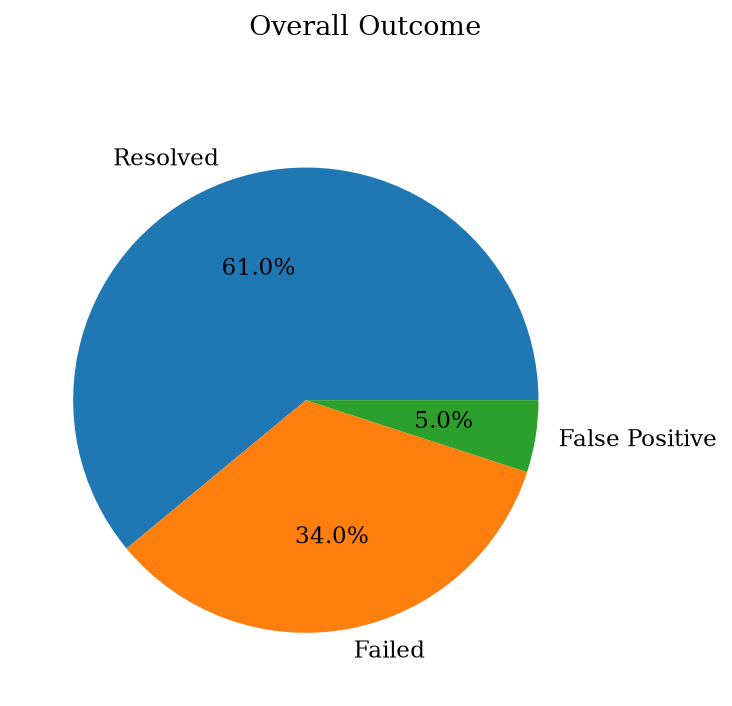

In [2]:
# Overall
OUTCOME_ORDER = ["Resolved", "Failed", "False Positive"]

OUTCOME_COLORS = {
    "Resolved": "#4caf50",
    "Failed": "#f44336",
    "False Positive": "#ff9800",
}

counts = (
    df["outcome"]
    .value_counts()
    .reindex(OUTCOME_ORDER, fill_value=0)
)

pie_chart_axis = counts.plot.pie("outcome", figsize=(5, 5), autopct="%1.1f%%", color=[OUTCOME_COLORS[o] for o in OUTCOME_ORDER])

pie_chart_axis.get_figure().suptitle("Overall Outcome")
pie_chart_axis.get_figure().tight_layout()
pie_chart_axis.get_figure().savefig("results/overall_outcome.png", bbox_inches="tight")
pie_chart_axis.get_figure().show()

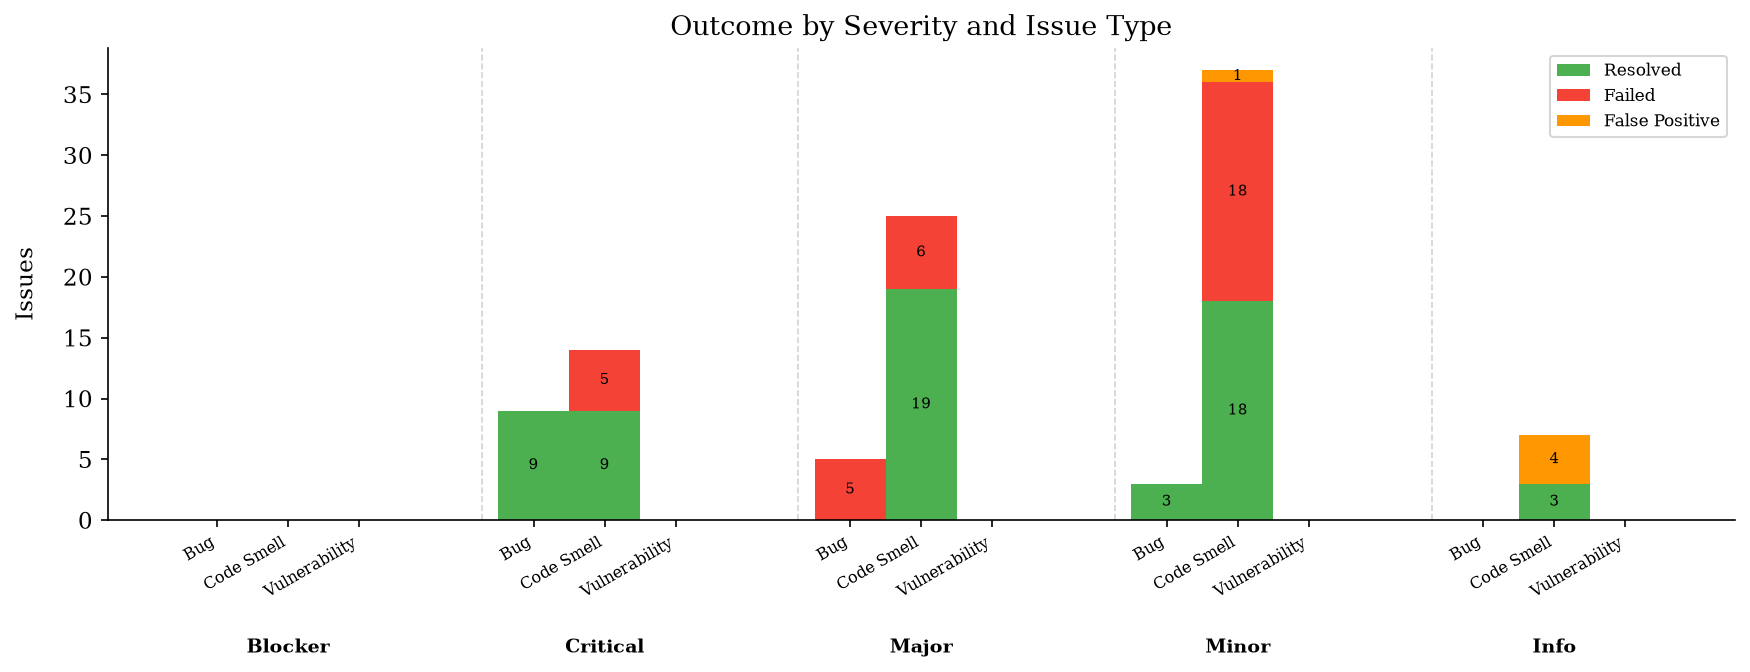

In [3]:
SEVERITY_ORDER = ["BLOCKER", "CRITICAL", "MAJOR", "MINOR", "INFO"]
TYPE_ORDER     = ["BUG", "CODE_SMELL", "VULNERABILITY"]
OUTCOME_ORDER  = ["Resolved", "Failed", "False Positive"]

def plot_outcome_grouped(ax=None, title="Outcome by Severity and Issue Type", save_path=None):
    mi = pd.MultiIndex.from_product(
        [SEVERITY_ORDER, TYPE_ORDER], names=["severity", "issue_type"]
    )
    pivot = (
        df.groupby(["severity", "issue_type", "outcome"])
        .size()
        .unstack(fill_value=0)
        .reindex(mi, fill_value=0)
        .reindex(columns=OUTCOME_ORDER, fill_value=0)
    )

    n_sev, n_type = len(SEVERITY_ORDER), len(TYPE_ORDER)
    bar_w, group_gap = 0.55, 0.8
    x_pos = [
        i * (n_type * bar_w + group_gap) + j * bar_w
        for i in range(n_sev) for j in range(n_type)
    ]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(14, 5))

    bottoms = np.zeros(n_sev * n_type)
    for outcome in OUTCOME_ORDER:
        vals = pivot[outcome].values
        bars = ax.bar(x_pos, vals, width=bar_w, bottom=bottoms,
                      color=OUTCOME_COLORS[outcome], label=outcome)
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_y() + bar.get_height() / 2,
                        str(int(v)), ha="center", va="center", fontsize=7)
        bottoms += vals

    ax.set_xticks(x_pos)
    ax.set_xticklabels(
        [string.capwords(TYPE_ORDER[j].replace("_", " ")) for _ in range(n_sev) for j in range(n_type)],
        fontsize=7.5, rotation=30, ha="right",
    )
    for i, sev in enumerate(SEVERITY_ORDER):
        center = i * (n_type * bar_w + group_gap) + (n_type - 1) * bar_w / 2
        ax.text(center, -0.25, string.capwords(sev),
                ha="center", va="top", fontsize=9, fontweight="bold",
                transform=ax.get_xaxis_transform())
    for i in range(1, n_sev):
        sep = i * (n_type * bar_w + group_gap) - group_gap / 2
        ax.axvline(sep, color="lightgray", linewidth=0.8, linestyle="--")

    ax.set_ylabel("Issues", labelpad=12)
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8)

    if standalone:
        fig.subplots_adjust(bottom=0.25)
        if save_path:
            fig.savefig(save_path, bbox_inches="tight")
        plt.show()

plot_outcome_grouped(save_path="results/outcome_by_severity_type.png")

In [4]:
# ── Tables ────────────────────────────────────────────────────
total = len(df)
print(
    f"Overall resolution rate : {df['resolved'].sum()}/{total} = {df['resolved'].mean()*100:.1f}%"
)
print(
    f"False positive rate     : {(df['outcome']=='False Positive').sum()}/{total} = {(df['outcome']=='False Positive').mean()*100:.1f}%"
)


def outcome_table(group_col, order):
    tbl = (
        pd.DataFrame(
            {
                "Total": df.groupby(group_col).size(),
                "Resolved": df[df["outcome"] == "Resolved"].groupby(group_col).size(),
                "Failed": df[df["outcome"] == "Failed"].groupby(group_col).size(),
                "False Positive": df[df["outcome"] == "False Positive"]
                .groupby(group_col)
                .size(),
            }
        )
        .fillna(0)
        .astype(int)
        .reindex(order, fill_value=0)
    )
    tbl["Rate (%)"] = (tbl["Resolved"] / tbl["Total"].replace(0, np.nan) * 100).round(1)
    return tbl


print("\nBy Severity:")
print(outcome_table("severity", SEVERITY_ORDER).to_string())

print("\nBy Type:")
print(outcome_table("issue_type", TYPE_ORDER).to_string())

Overall resolution rate : 61/100 = 61.0%
False positive rate     : 5/100 = 5.0%

By Severity:
          Total  Resolved  Failed  False Positive  Rate (%)
severity                                                   
BLOCKER       0         0       0               0       NaN
CRITICAL     23        18       5               0      78.3
MAJOR        30        19      11               0      63.3
MINOR        40        21      18               1      52.5
INFO          7         3       0               4      42.9

By Type:
               Total  Resolved  Failed  False Positive  Rate (%)
issue_type                                                      
BUG               17        12       5               0      70.6
CODE_SMELL        83        49      29               5      59.0
VULNERABILITY      0         0       0               0       NaN


In [5]:
fp_df = df[df["outcome"] == "False Positive"]
print(f"False Positives: {len(fp_df)} / {len(df)} = {len(fp_df)/len(df)*100:.1f}%")

print("\nBy Severity:")
print(fp_df["severity"].value_counts().to_string())

print("\nBy Rule:")
print(fp_df["rule"].value_counts().to_string())
print(fp_df.to_string())

False Positives: 5 / 100 = 5.0%

By Severity:
severity
INFO     4
MINOR    1

By Rule:
rule
typescript:S1135    3
javascript:S1135    1
typescript:S7781    1
     type                                    id              rule severity                                                                       file     function  resolved  total_duration_seconds  dur_summarizer  dur_remediation  dur_validation  dur_documentation  issue_type         outcome  attempts        file_short                                               rejection_reason_0 rejection_reason_1 rejection_reason_2
39  issue  8bc598d3-fc70-43ec-a172-bcb9c701d77d  javascript:S1135     INFO                                packages/mermaid/src/dagre-wrapper/edges.js    <snippet>     False                    9.49            0.00             9.48             NaN                NaN  CODE_SMELL  False Positive         0          edges.js                                                                                                  

In [6]:
print(df.loc[(df['outcome'].isin(['Failed', 'False Positive'])) & (df['severity'] == 'MAJOR') & (df['issue_type']== "BUG")].to_string())


     type                                    id              rule severity                                                        file     function  resolved  total_duration_seconds  dur_summarizer  dur_remediation  dur_validation  dur_documentation issue_type outcome  attempts           file_short                                                                                                                                                                                                                                                                  rejection_reason_0                                               rejection_reason_1                                                                                                                                              rejection_reason_2
8   issue  d68e672a-9b2e-4f5f-8799-06cc611a06da  javascript:S3923    MAJOR           packages/mermaid/src/diagrams/sequence/svgDraw.js    <snippet>     False                  815.55            0.00  

In [7]:
AGENT_COLS   = ["dur_summarizer", "dur_remediation",       "dur_validation",       "dur_documentation"]
AGENT_COLS_C = ["dur_summarizer", "dur_remediation_total", "dur_validation_total", "dur_documentation"]
AGENT_LABELS = ["Summarizer", "Remediation", "Validation", "Documentation"]
AGENT_COLORS = ["#42a5f5", "#ef5350", "#66bb6a", "#ffa726"]

# Remediation and validation log only the last attempt — scale by attempt count
df["dur_remediation_total"] = df["dur_remediation"] * df["attempts"]
df["dur_validation_total"]  = df["dur_validation"]  * df["attempts"]

# Multiple issues sharing a function are processed together (one agent call).
# Deduplicate to one row per (file, function) before computing means.
fn_df = df.groupby(["file", "function"])[
    AGENT_COLS_C + ["total_duration_seconds", "outcome"]
].first().reset_index()
N_FN = len(fn_df)

print(f"Issues: {len(df)}  |  Unique function groups: {N_FN}")

print("\n=== Total Wall-Clock Time per function (seconds) ===")
t = fn_df["total_duration_seconds"]
stats = pd.DataFrame({
    "Mean": [t.mean()], "Median": [t.median()],
    "Std":  [t.std()],  "Min":    [t.min()], "Max": [t.max()],
}).round(1)
print(stats.to_string(index=False))

print(f"\nPer-agent mean per function (n={N_FN}, NaN→0, corrected for retries):")
agent_means_fn = fn_df[AGENT_COLS_C].fillna(0).mean().rename(dict(zip(AGENT_COLS_C, AGENT_LABELS)))
print(agent_means_fn.round(1).to_string())
print(f"  {'Sum':<18} {agent_means_fn.sum():.1f}s  (wall-clock mean: {t.mean():.1f}s)")

print(f"\nMean agent time by outcome (function-level, NaN→0, corrected):")
agent_by_outcome = (
    fn_df.groupby("outcome")[AGENT_COLS_C]
    .apply(lambda g: g.fillna(0).mean())
    .round(1)
)
agent_by_outcome.columns = pd.Index(AGENT_LABELS)
print(agent_by_outcome.to_string())

Issues: 100  |  Unique function groups: 80

=== Total Wall-Clock Time per function (seconds) ===
 Mean  Median   Std  Min    Max
451.8   405.2 252.1  9.5 1049.6

Per-agent mean per function (n=80, NaN→0, corrected for retries):
Summarizer        38.5
Remediation      222.8
Validation       106.1
Documentation     75.4
  Sum                442.8s  (wall-clock mean: 451.8s)

Mean agent time by outcome (function-level, NaN→0, corrected):
                Summarizer  Remediation  Validation  Documentation
outcome                                                           
Failed                30.6        467.0       147.0            3.9
False Positive        14.5         50.5        35.7            0.0
Resolved              44.4        131.4        94.7          114.2


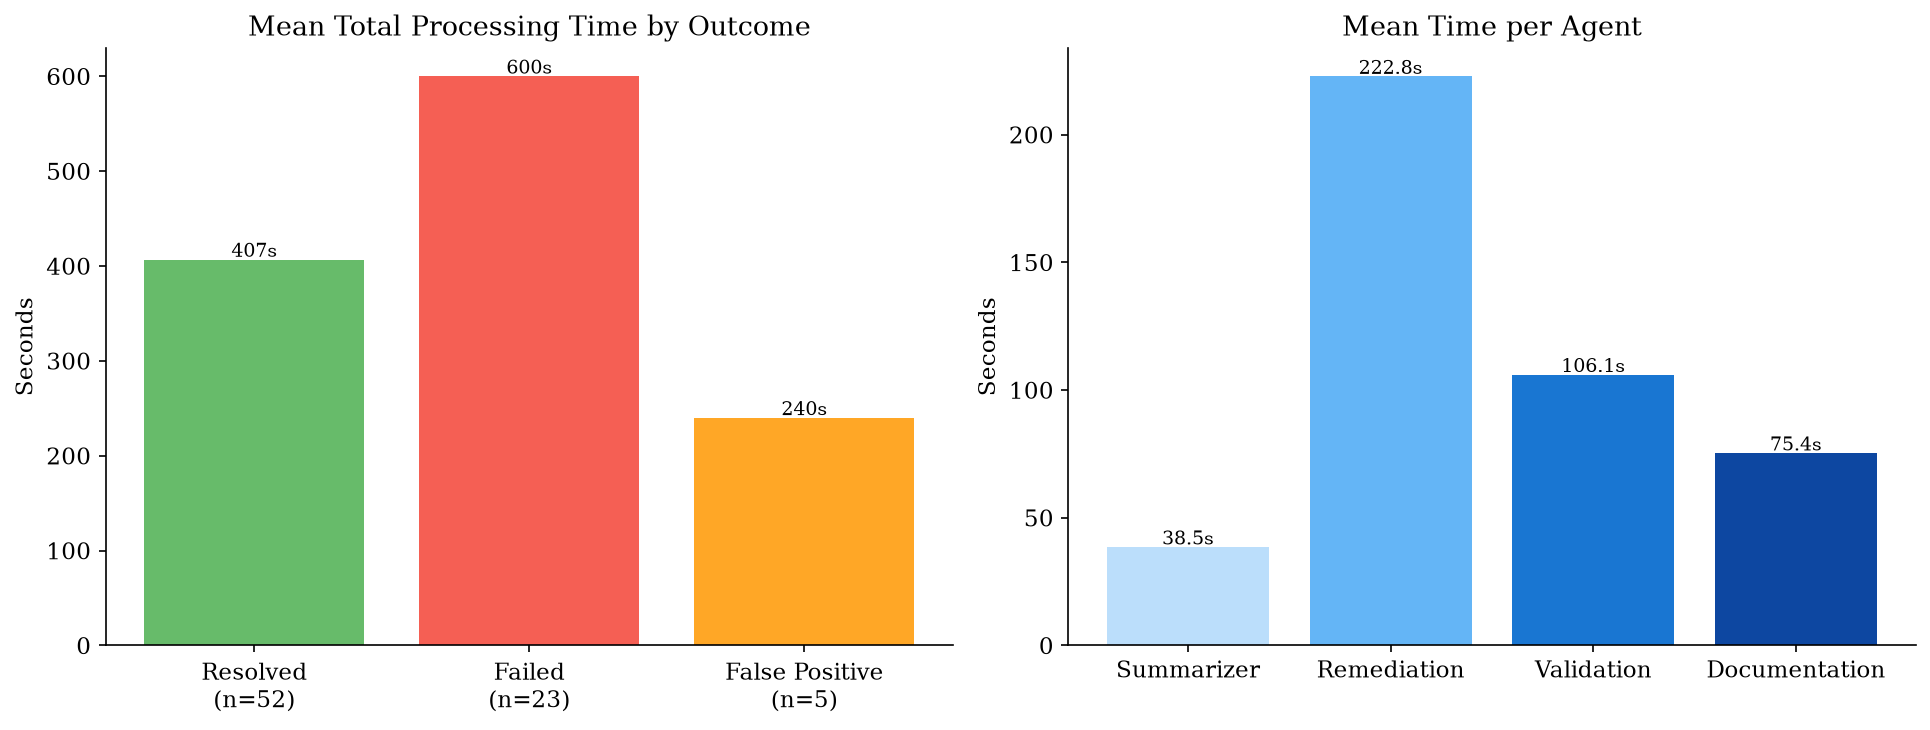

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: mean total time per outcome
OUTCOME_LIST = ["Resolved", "Failed", "False Positive"]
means  = [fn_df[fn_df["outcome"] == o]["total_duration_seconds"].mean() for o in OUTCOME_LIST]
counts = [fn_df[fn_df["outcome"] == o]["total_duration_seconds"].count() for o in OUTCOME_LIST]

bars = axes[0].bar(OUTCOME_LIST, means, color=[OUTCOME_COLORS[o] for o in OUTCOME_LIST], alpha=0.85)
for bar, val in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                 f"{val:.0f}s", ha="center", fontsize=9)
axes[0].set_xticks(range(len(OUTCOME_LIST)))
axes[0].set_xticklabels([f"{o}\n(n={c})" for o, c in zip(OUTCOME_LIST, counts)])
axes[0].set_title("Mean Total Processing Time by Outcome")
axes[0].set_ylabel("Seconds")

# Right: mean time per agent — shades of blue
AGENT_BLUES = ["#bbdefb", "#64b5f6", "#1976d2", "#0d47a1"]
means_fn = fn_df[AGENT_COLS_C].fillna(0).mean().values
bars = axes[1].bar(AGENT_LABELS, means_fn, color=AGENT_BLUES)
for bar, val in zip(bars, means_fn):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{val:.1f}s", ha="center", fontsize=9)
axes[1].set_title("Mean Time per Agent")
axes[1].set_ylabel("Seconds")

plt.tight_layout()
plt.savefig("results/remediation_time.png", bbox_inches="tight")
plt.show()

In [9]:
JUDGE = Path("results/fix_assessment.jsonl")

judge_records = []
with JUDGE.open(encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        judge_records.append(json.loads(line))

judge_df = pd.DataFrame(judge_records)[
    ["id", "label", "confidence", "acceptable",
     "correctness", "semantic_preservation", "no_regression", "idiomaticity", "notes"]
]

df = df.merge(judge_df, on="id", how="left")

assessed = df["label"].notna()
print(f"Issues with judge assessment : {assessed.sum()} / {len(df)}")
print(f"\nLabel distribution:")
print(df.loc[assessed, "label"].value_counts().to_string())
print(f"\nAcceptable : {df.loc[assessed, 'acceptable'].sum()} / {assessed.sum()}")
print(f"Confidence distribution:")
print(df.loc[assessed, "confidence"].value_counts().to_string())

Issues with judge assessment : 100 / 100

Label distribution:
label
correct              53
incorrect            40
unsafe                6
partially correct     1

Acceptable : 53 / 100
Confidence distribution:
confidence
high      90
medium    10


In [10]:
# Cross-tabulation: system outcome vs judge label
# label order: correct → partially correct → unsafe → incorrect
LABEL_ORDER   = ["correct", "partially correct", "unsafe", "incorrect"]
OUTCOME_ORDER_ = ["Resolved", "Failed", "False Positive"]

assessed = df["label"].notna()
cross = (
    df[assessed]
    .groupby(["outcome", "label"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=OUTCOME_ORDER_, fill_value=0)
    .reindex(columns=LABEL_ORDER, fill_value=0)
)
cross["Total"] = cross.sum(axis=1)
print("System outcome  ×  Judge label\n")
print(cross.to_string())

print("\n── Discrepancies ──────────────────────────────────────────")
# System resolved but judge says not fully correct
over_reported = df[assessed & (df["outcome"] == "Resolved") & (df["label"] != "correct")]
print(f"\nResolved by system  but judge != correct : {len(over_reported)}")
if len(over_reported):
    print(over_reported[["id", "file_short", "rule", "function", "label", "outcome", "confidence", "notes"]].to_string(index=False))

# System did not resolve but judge says correct
under_reported = df[assessed & (df["outcome"] != "Resolved") & (df["label"] == "correct")]
print(f"\nNot resolved by system  but judge = correct : {len(under_reported)}")
if len(under_reported):
    print(under_reported[["id", "file_short", "rule", "function", "label", "outcome", "confidence", "notes"]].to_string(index=False))

System outcome  ×  Judge label

label           correct  partially correct  unsafe  incorrect  Total
outcome                                                             
Resolved             53                  1       6          1     61
Failed                0                  0       0         34     34
False Positive        0                  0       0          5      5

── Discrepancies ──────────────────────────────────────────

Resolved by system  but judge != correct : 8
                                  id                  file_short             rule                            function             label  outcome confidence                                                                                                                                                                                 notes
d99bd513-43f0-4cba-be44-866423d88e99     materializedGeometry.ts typescript:S7778  resolveRenderedOrthogonalCrossings            unsafe Resolved       high                       

1. ISSUE RESOLUTION RATE
  Pipeline-marked resolved             : 61 / 100 = 61.0%
  SonarQube-confirmed closed           : 59 / 100 = 59.0%
  True remediation (code fixed, 3-way)     : 53 / 100 = 53.0%
  Adjusted true remediation (+ verified FP): 57 / 100 = 57.0%

  By Severity:
          Sampled  Fixed(3way)  Adjusted  Fixed (%)  Adjusted (%)
severity                                                         
BLOCKER         0            0         0        NaN           NaN
CRITICAL       23           15        15       65.2          65.2
MAJOR          30           17        17       56.7          56.7
MINOR          40           18        18       45.0          45.0
INFO            7            3         7       42.9         100.0

  By Issue Type:
               Sampled  Fixed(3way)  Adjusted  Fixed (%)  Adjusted (%)
issue_type                                                            
BUG                 17           11        11       64.7          64.7
CODE_SMELL          83    

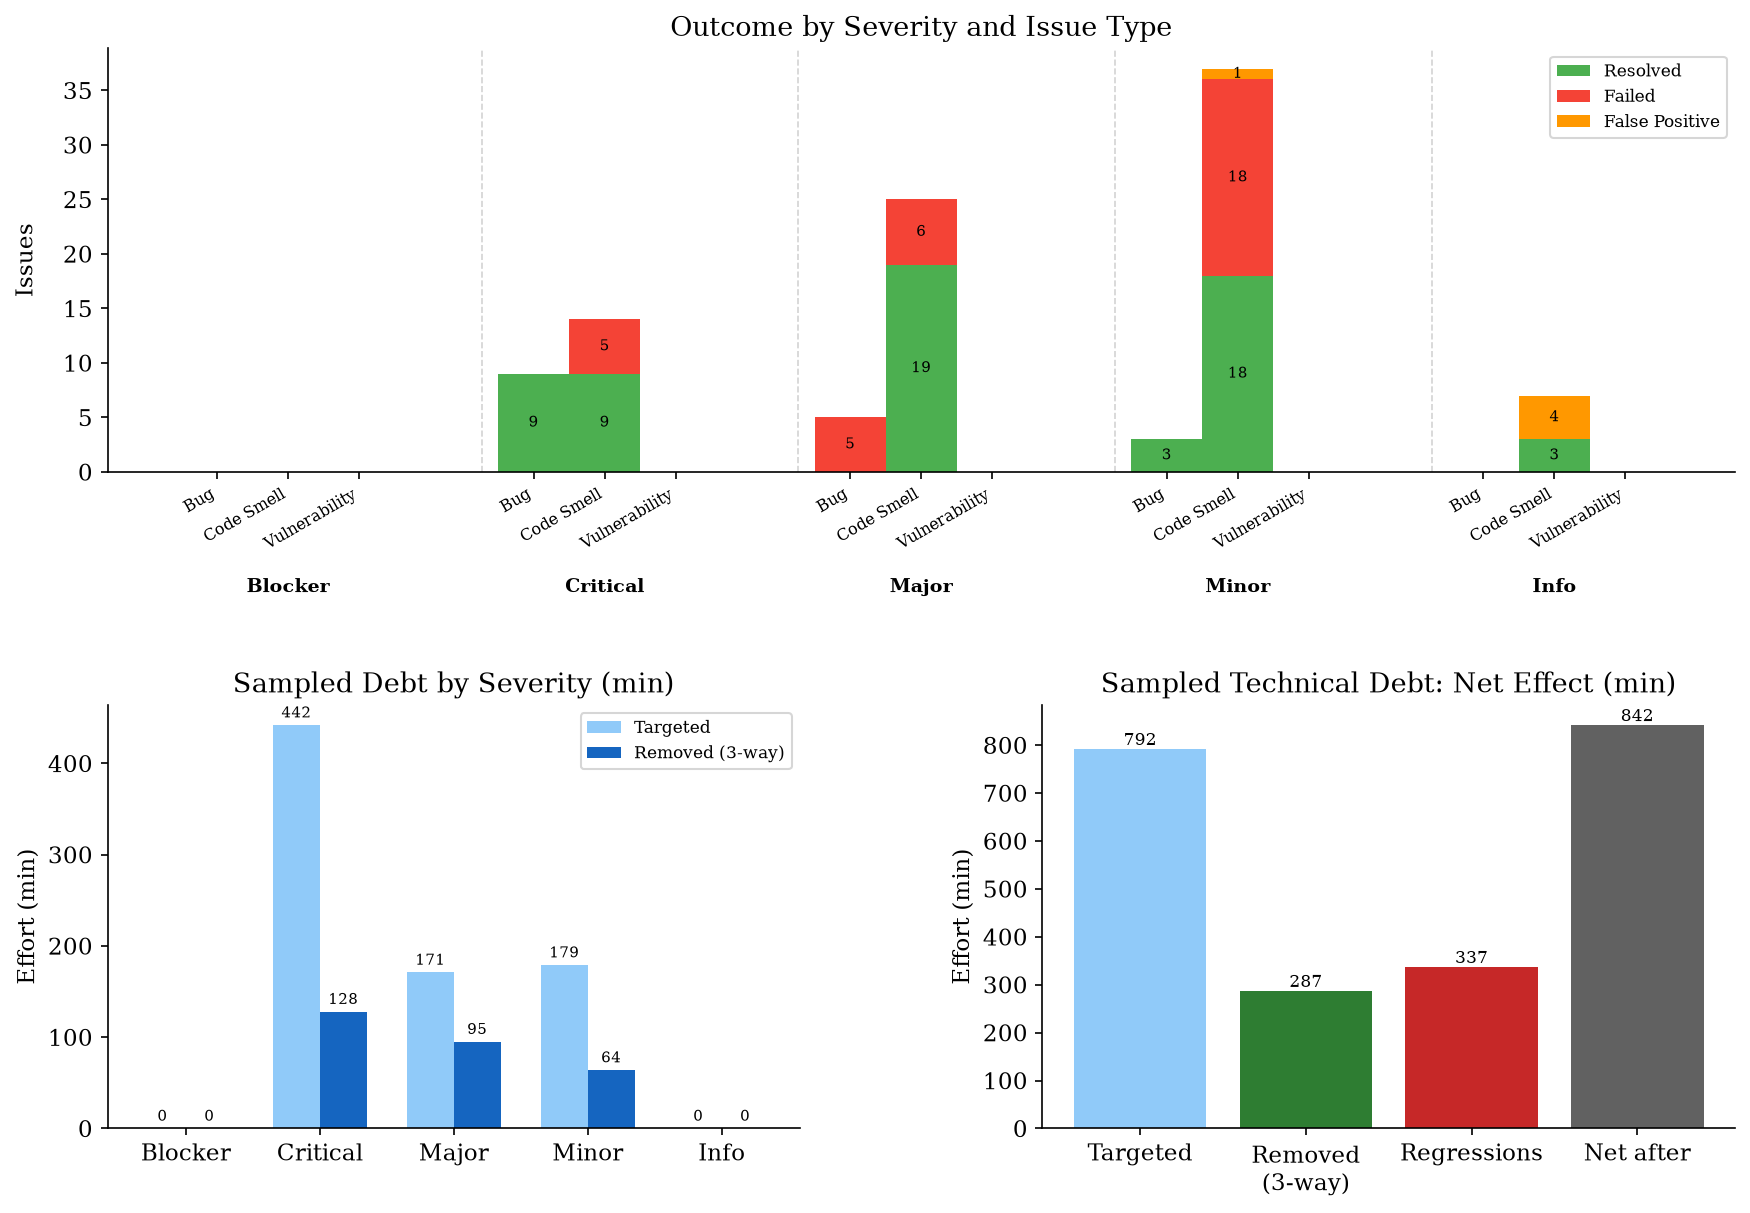

In [11]:
# ── Pre / Post SonarQube Analysis ────────────────────────────
from collections import Counter

before_raw = json.load(Path("data/sonar_report_mermaid.json").open())
after_raw  = json.load(Path("data/sonar_report_mermaid_after.json").open())
strat_raw  = json.load(Path("data/sonar_report_mermaid_stratified.json").open())

strat_map       = {i["id"]: i for i in strat_raw["issues"]}
before_ids_full = {i["id"] for i in before_raw["issues"]}
after_ids_full  = {i["id"] for i in after_raw["issues"]}
bm, am          = before_raw["measures"], after_raw["measures"]

# ── Per-issue evaluation signals, weighted by SonarQube effort ─
# effort_minutes is SonarQube's estimate of the debt each issue carries.
def _effort(i):
    e = strat_map.get(i, {}).get("effort_minutes")
    return e if e else 0

df["effort"]        = df["id"].map(_effort)
df["sonar_closed"]  = ~df["id"].isin(after_ids_full)       # absent from post-scan => closed
df["judge_correct"] = df["label"] == "correct"
df["threeway"]      = df["resolved"] & df["sonar_closed"] & df["judge_correct"]

# ── Independent verification of the pipeline's false-positive claims ──
# The pipeline declined some issues as false positives. An independent judge
# re-checked each and returned "won't fix" (a genuine FP, no change warranted)
# or "fix" (a real issue the pipeline wrongly declined, which counts as a failure).
FP_JUDGE = Path("results/llm_as_judge_false_positive_assessmet.jsonl")
fp_verdict = {}
with FP_JUDGE.open(encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            r = json.loads(line)
            fp_verdict[r["id"]] = r["verdict"]

df["fp_verdict"] = df["id"].map(fp_verdict)
genuine_fp    = df["fp_verdict"] == "won't fix"   # verified: no fix needed
overturned_fp = df["fp_verdict"] == "fix"          # wrongly declined -> counts as failure

# Refined outcome: split the pipeline's FP bucket by the judge's verdict.
def _refine(row):
    if row["outcome"] == "False Positive":
        return "Declined (verified)" if row["fp_verdict"] == "won't fix" else "Failed"
    return row["outcome"]
df["outcome_v2"] = df.apply(_refine, axis=1)

# Adjusted true remediation credits both a verified fix and a false positive the
# pipeline correctly declined. Verified FPs are folded in (not discarded), since
# correctly declining a non-defect is the right action and is itself a decision
# made by the Remediation agent's triage.
df["adjusted"] = df["threeway"] | genuine_fp

# Files the system changed at least one issue in.
touched_components = {
    strat_map[row.id]["component"]
    for row in df[df["resolved"]].itertuples()
    if row.id in strat_map
}

# ── 1. Issue Resolution Rate ──────────────────────────────────
print("=" * 62)
print("1. ISSUE RESOLUTION RATE")
print("=" * 62)
print(f"  Pipeline-marked resolved             : {df['resolved'].sum()} / {len(df)} = {df['resolved'].mean()*100:.1f}%")
print(f"  SonarQube-confirmed closed           : {df['sonar_closed'].sum()} / {len(df)} = {df['sonar_closed'].mean()*100:.1f}%")
print(f"  True remediation (code fixed, 3-way)     : {df['threeway'].sum()} / {len(df)} = {df['threeway'].mean()*100:.1f}%")
print(f"  Adjusted true remediation (+ verified FP): {df['adjusted'].sum()} / {len(df)} = {df['adjusted'].mean()*100:.1f}%")

def threeway_by(group_col, order):
    tbl = pd.DataFrame({
        "Sampled":     df.groupby(group_col).size(),
        "Fixed(3way)": df[df["threeway"]].groupby(group_col).size(),
        "Adjusted":    df[df["adjusted"]].groupby(group_col).size(),
    }).fillna(0).astype(int).reindex(order, fill_value=0)
    tbl["Fixed (%)"]    = (tbl["Fixed(3way)"] / tbl["Sampled"].replace(0, np.nan) * 100).round(1)
    tbl["Adjusted (%)"] = (tbl["Adjusted"]    / tbl["Sampled"].replace(0, np.nan) * 100).round(1)
    return tbl

print("\n  By Severity:")
print(threeway_by("severity", SEVERITY_ORDER).to_string())
print("\n  By Issue Type:")
print(threeway_by("issue_type", TYPE_ORDER).to_string())

# ── 2. False Positive Rate (judge-verified) ───────────────────
print()
print("=" * 62)
print("2. FALSE POSITIVE RATE  (independently verified)")
print("=" * 62)
claimed = df["outcome"] == "False Positive"
print(f"  Pipeline-claimed false positives : {claimed.sum()} / {len(df)} = {claimed.mean()*100:.1f}%")
print(f"  Judge-verified genuine (won't fix): {genuine_fp.sum()}  -> folded into adjusted true remediation")
print(f"  Judge-overturned (real issue)     : {overturned_fp.sum()}  -> counted as Failed")
print("\n  Per-claim verdicts:")
print(df.loc[claimed, ["file_short", "rule", "severity", "fp_verdict"]].to_string(index=False))

# ── 3. Regression Rate ────────────────────────────────────────
before_by_comp, after_by_comp = {}, {}
for i in before_raw["issues"]:
    before_by_comp.setdefault(i["component"], set()).add(i["id"])
for i in after_raw["issues"]:
    after_by_comp.setdefault(i["component"], set()).add(i["id"])

regression_files, reg_issues = {}, []
for comp in touched_components:
    new_ids = after_by_comp.get(comp, set()) - before_by_comp.get(comp, set())
    if new_ids:
        issues = [i for i in after_raw["issues"] if i["id"] in new_ids]
        regression_files[comp.split(":")[-1]] = issues
        reg_issues += issues

n_touched   = len(touched_components)
n_regressed = len(regression_files)
total_new   = sum(len(v) for v in regression_files.values())
reg_debt    = sum((i.get("effort_minutes") or 0) for i in reg_issues)

print()
print("=" * 62)
print("3. REGRESSION RATE")
print("=" * 62)
print(f"  Files with a resolved issue      : {n_touched}")
print(f"  Files with net-new issues        : {n_regressed}  ({n_regressed/n_touched*100:.1f}%)")
print(f"  Total net-new issues introduced  : {total_new}")
print(f"  Debt introduced by regressions   : {reg_debt} min")
print("\n  Affected files:")
for fname, issues in sorted(regression_files.items(), key=lambda x: -len(x[1])):
    sev_str = "  ".join(f"{s}:{c}" for s, c in Counter(i["severity"] for i in issues).most_common())
    print(f"    {fname:<55s} {len(issues):2d} new  [{sev_str}]")

# ── 4. Quality Delta  (scoped to the sampled issues, effort-weighted) ──
# Denominator is the debt the pipeline was actually pointed at (the sample),
# not every issue in the touched files. Verified false positives carry zero
# SonarQube effort, so they do not affect the debt totals. Regressions are
# added back on the "after" side so the net figure reflects the true impact.
print()
print("=" * 62)
print("4. QUALITY DELTA  (sampled issues, effort-weighted)")
print("=" * 62)

def debt_delta(group_col, order):
    rows = []
    for k in order:
        b = df[df[group_col] == k]
        r = df[df["threeway"] & (df[group_col] == k)]
        s = df[df["sonar_closed"] & ~genuine_fp & (df[group_col] == k)]
        rows.append({
            group_col: k,
            "Issues": len(b), "Debt(min)": int(b["effort"].sum()),
            "Resolved(3way)": len(r), "Debt removed(3way)": int(r["effort"].sum()),
            "Removed(Sonar)": len(s), "Debt removed(Sonar)": int(s["effort"].sum()),
        })
    return pd.DataFrame(rows)

print("\n  By Severity:")
print(debt_delta("severity", SEVERITY_ORDER).to_string(index=False))
print("\n  By Issue Type:")
print(debt_delta("issue_type", TYPE_ORDER).to_string(index=False))

targeted_debt  = int(df["effort"].sum())
removed_3way   = int(df.loc[df["threeway"], "effort"].sum())
removed_sonar  = int(df.loc[df["sonar_closed"] & ~genuine_fp, "effort"].sum())
net_3way       = reg_debt - removed_3way
net_sonar      = reg_debt - removed_sonar

print(f"\n  Targeted debt (sample)         : {targeted_debt} min ({targeted_debt/60:.1f} h) over {len(df)} issues")
print(f"  Debt removed, three-way        : {removed_3way} min ({removed_3way/targeted_debt*100:.1f}% of targeted)")
print(f"  Debt removed, SonarQube        : {removed_sonar} min ({removed_sonar/targeted_debt*100:.1f}% of targeted)")
print(f"  Debt added by regressions      : +{reg_debt} min")
print(f"  NET debt change, three-way     : {net_3way:+d} min ({net_3way/targeted_debt*100:+.1f}%)  -> {targeted_debt} -> {targeted_debt+net_3way} min")
print(f"  NET debt change, SonarQube     : {net_sonar:+d} min ({net_sonar/targeted_debt*100:+.1f}%)  -> {targeted_debt} -> {targeted_debt+net_sonar} min")

# Complexity remains a project-wide measure (per-file not available in report).
print(f"\n  Cognitive complexity (project-wide) : {bm['cognitive_complexity']:.0f} -> {am['cognitive_complexity']:.0f}  ({am['cognitive_complexity']-bm['cognitive_complexity']:+.0f})")
print(f"  Cyclomatic complexity (project-wide): {bm['cyclomatic_complexity']:.0f} -> {am['cyclomatic_complexity']:.0f}  ({am['cyclomatic_complexity']-bm['cyclomatic_complexity']:+.0f})")

# ── 5. Three-Way Discrepancy: AGENT × SONAR × JUDGE ───────────
print()
print("=" * 62)
print("5. THREE-WAY DISCREPANCY: AGENT  ×  SONAR  ×  JUDGE")
print("=" * 62)

assessed = df["label"].notna()
tri = df[assessed].copy()
print("\n  Counts by (agent_resolved, sonar_closed, judge_correct):\n")
summary = (
    tri.groupby(["resolved", "sonar_closed", "judge_correct"])
    .size()
    .reset_index(name="n")
    .rename(columns={"resolved": "agent", "sonar_closed": "sonar", "judge_correct": "judge"})
)
for c in ["agent", "sonar", "judge"]:
    summary[c] = summary[c].map({True: "✓", False: "✗"})
print(summary.to_string(index=False))

# ── Plots ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 9))
gs  = fig.add_gridspec(2, 2, hspace=0.55, wspace=0.35)

ax_top = fig.add_subplot(gs[0, :])
plot_outcome_grouped(ax=ax_top)
fig.subplots_adjust(bottom=0.08)

# Bottom-left: sampled debt by severity, targeted vs three-way removed
x, bw = np.arange(len(SEVERITY_ORDER)), 0.35
ax_bl = fig.add_subplot(gs[1, 0])
tgt = [int(df.loc[df["severity"] == s, "effort"].sum()) for s in SEVERITY_ORDER]
rem = [int(df.loc[df["threeway"] & (df["severity"] == s), "effort"].sum()) for s in SEVERITY_ORDER]
for vals, offset, color, lbl in [
    (tgt, -bw/2, "#90caf9", "Targeted"),
    (rem, +bw/2, "#1565c0", "Removed (3-way)"),
]:
    bars = ax_bl.bar(x + offset, vals, bw, label=lbl, color=color)
    ax_bl.bar_label(bars, fontsize=7, padding=2)
ax_bl.set_xticks(x)
ax_bl.set_xticklabels([s.capitalize() for s in SEVERITY_ORDER])
ax_bl.set_title("Sampled Debt by Severity (min)")
ax_bl.set_ylabel("Effort (min)")
ax_bl.legend(fontsize=8)

# Bottom-right: net debt over the sampled issues
ax_br = fig.add_subplot(gs[1, 1])
labels = ["Targeted", "Removed\n(3-way)", "Regressions", "Net after"]
vals   = [targeted_debt, removed_3way, reg_debt, targeted_debt + net_3way]
colors = ["#90caf9", "#2e7d32", "#c62828", "#616161"]
bars = ax_br.bar(labels, vals, color=colors)
ax_br.bar_label(bars, fontsize=8)
ax_br.set_title("Sampled Technical Debt: Net Effect (min)")
ax_br.set_ylabel("Effort (min)")

fig.savefig("results/pre_post_analysis.png", bbox_inches="tight")
plt.show()
